# Stock Price Prediction

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [8]:
data = pd.read_csv("stock_data.csv")

In [11]:
close_price = data['MSFT'].values.reshape(-1,1)

In [12]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(close_price)

# Create Training Dataset

In [14]:
import numpy as np

In [30]:
X_train = []
y_train = []

In [16]:
for i in range(60, len(scaled_data)):
    X_train.append(scaled_data[i-60:i, 0])
    y_train.append(scaled_data[i, 0])

In [17]:
X_train, y_train = np.array(X_train), np.array(y_train)

In [18]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Build LSTM Model

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [20]:
model = Sequential()

In [21]:
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(Dropout(0.2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
model.add(LSTM(50))
model.add(Dropout(0.2))

In [23]:
model.add(Dense(1))

In [24]:
model.compile(optimizer='adam', loss='mean_squared_error')

# Train Model

In [25]:
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - loss: 0.0351
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.0025
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0023
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 0.0023
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0018
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0019
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.0017
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0016
Epoch 9/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.0016
Epoch 10/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 0.0017


In [29]:
model.save("../src/lstm_model.h5")

In [26]:
import matplotlib.pyplot as plt

In [27]:
predictions = model.predict(X_train)

71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


# Prediction & Visualization

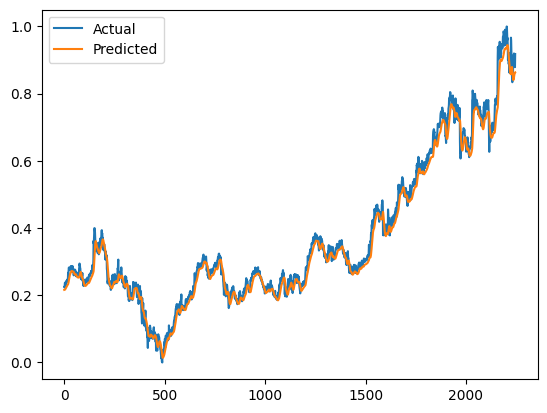

In [28]:
plt.plot(y_train, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.show()